In [ ]:
# =========================================================
# SETUP (To run before each session)
# =========================================================

# Libraries
from pathlib import Path
import pandas as pd
import gzip
import re
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

current_dir = Path.cwd()

if (current_dir / "metadata" / "sample_sheet.csv").exists():
    project_dir = current_dir

elif (
    current_dir.parent
    / "metadata"
    / "sample_sheet.csv"
).exists():
    project_dir = current_dir.parent

else:
    raise FileNotFoundError(
        "Could not locate metadata/sample_sheet.csv. "
        "Run this cell from the project or notebooks folder."
    )


metadata_path = (
    project_dir
    / "metadata"
    / "sample_sheet.csv"
)

fastq_dir = (
    project_dir
    / "data"
    / "fastq"
    / "extracted"
)

alignment_dir = (
    project_dir
    / "results"
    / "alignment"
)

output_dir = (
    project_dir
    / "results"
    / "counts"
    / "detected_genes"
)

combined_output_path = (
    project_dir
    / "results"
    / "counts"
    / "detected_genes_by_sample.csv"
)

summary_path = (
    project_dir
    / "results"
    / "counts"
    / "library_genes_maprate_counts.csv"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

vst_path = (
    project_dir
    / "results"
    / "counts"
    / "vst_counts.csv"
)

scores_path = (
    project_dir
    / "results"
    / "counts"
    / "vst_pca_scores.csv"
)

pca_plot_path = (
    project_dir
    / "results"
    / "counts"
    / "vst_pca_plot.png"
)

pca_scores_path = (
    project_dir
    / "results"
    / "counts"
    / "vst_pca_scores.csv"
)


pc_scores_vs_mng_plot_path = (
    project_dir
    / "results"
    / "counts"
    / "vst_pc_scores_vs_mng.png"
)


metadata = pd.read_csv(metadata_path)
pca_scores = pd.read_csv(pca_scores_path)
vst_counts = pd.read_csv(vst_path)

rai1_gene_id = "ENSG00000108557.22"



In [ ]:
# TASK 1A: Creating a metadata sheet (sample_sheet.csv)
# =========================================================

dtag_dosage_conditions = [
    ("50nM", 50, 0),
    ("5nM", 5, 0.25),
    ("1nM", 1, 0.50),
    ("0p5nM", 0.5, 0.75),
    ("CTRL", 0, 1),
]

flow_measurements = [
    (0.0314843, 0.2053973, 0.4957746, 0.7211394, 1),
    (0.0380282, 0.156338, None, 0.8112676, 1),
    (0.0299572, 0.1540656, 0.4793153, 0.823109, 1),
]

#reading from Nanodrop (ng/ul)
rna_conc = [ 
    (549.082, 576.79, 442.28, 566.892, 579.109),
    (438.539, 466.334, 459.199, 410.552, 439.592),
    (453.945, 463.603, 461.877, 453.87, 422.983),
]

rin = [ 
    (9, 8.6, 9.1, 9.2, 9.1),
    (9.2, 9.3, 9.1, 9, 9),
    (9.3, 9.1, 8.9, 9.2, 9),
]

new_rows = []

for replicate in range(1, 4):
    for condition_name, concentration, nominal_dosage_pct in dtag_dosage_conditions:

        sample_id = f"B2_{condition_name}_r{replicate}"

        # sample number = 0-14
        sample_num = (replicate - 1) * len(dtag_dosage_conditions) + dtag_dosage_conditions.index((condition_name, concentration, nominal_dosage_pct))
        # condition number = 0-4 (0=1, 1=0.75, 2=0.50, 3=0.25, 4=0)
        condition_num = dtag_dosage_conditions.index((condition_name, concentration, nominal_dosage_pct))

        row = {
            # --- identifiers ---
            "sample_id": sample_id,
            "count_column_name": sample_id,
            "fastq_prefix": "NS.X0338.004.UDP0" 
                 + str(273 + sample_num) + "V3_i7" 
                 if 12 <= sample_num <= 14
                 else "NS.X0338.004.UDP0" + str(273 + sample_num) + "_i7",
            # --- dosage ---
            "dtag_conc_nM": concentration,
            "nominal_dosage_pct": nominal_dosage_pct,
            # --- flow cytometry / mNeonGreen ---
            "mng_measured_pct": flow_measurements[replicate - 1][condition_num],
            "mng_summary_stat": "median",
            "mng_autofluor_corrected": "yes",
            "fcs_file": "B2" + f"_{concentration}" + "nM_rep" + f"{replicate}" + ".fcs",
            "flow_reference_sample": "WT_0nM_rep" + f"{replicate}" + ".fcs",
            # --- replicate / culture history ---
            "replicate": replicate,
            "differentiation_batch": 1,
            "differentiation_date": None,
            "treatment_batch": (
                "P7_0624"
                if replicate == 1 and condition_num != 2
                else "P8_0701"
            ),
            "treatment_date": (
                "2026-06-24"
                if replicate == 1 and condition_num != 2
                else "2026-07-01"
            ),
            "harvest_date": (
                "2026-06-26"
                if replicate == 1 and condition_num != 2
                else "2026-07-03"
            ),
            "passage_number": (
                7
                if replicate == 1 and condition_num != 2
                else 8
            ),
            "cells_harvested": "NA", #exact cell counts were not measured, but harvested 4 days after plating at 4 * 10^6cells/well
            # --- RNA / library prep ---
            "rna_yield_ng": rna_conc[replicate - 1][condition_num] * 60, #concentration (ng/ul) * volume submitted (ul)
            "rin": rin[replicate - 1][condition_num],
            "spike_in_added": "NA",
            "spike_in_amount": "NA",
            "library_prep_batch": 1,
            "library_prep_kit": "polyA",
            # --- sequencing ---
            "sequencing_run": "X0338",
            "lane": "004",
            # --- free text ---
            "notes": None,
        }

        new_rows.append(row)


# Load the existing sample sheet
df = pd.read_csv(metadata_path)

# Convert the rows created in Cell 2 into a DataFrame
new_df = pd.DataFrame(new_rows)

# Check that Cell 2 generated valid rows
if new_df.empty:
    raise ValueError(
        "new_rows is empty. Rerun Cell 2 before running this cell."
    )

if "sample_id" not in new_df.columns:
    raise KeyError(
        "Cell 2 must include 'sample_id' in each row dictionary."
    )

# Remove duplicate generated samples, keeping the newest version
new_df = new_df.drop_duplicates(
    subset="sample_id",
    keep="last"
).copy()

# Remove empty and example rows from the existing sample sheet
if "sample_id" in df.columns:
    df = df[df["sample_id"].notna()].copy()
    df = df[df["sample_id"] != "EXAMPLE_DELETE_THIS_ROW"].copy()
else:
    # Allow creation from Cell 2 if the existing CSV has no sample_id column
    df = pd.DataFrame()

# Use the dictionary order from row = {...} in Cell 2
new_column_order = list(new_df.columns)

# Keep any existing CSV columns that are not generated by Cell 2
existing_extra_columns = [
    column
    for column in df.columns
    if column not in new_column_order
]

final_column_order = new_column_order + existing_extra_columns

# Give both DataFrames the same columns and column order
df = df.reindex(columns=final_column_order)
new_df = new_df.reindex(columns=final_column_order)

# Remove old versions of samples that are being regenerated
if not df.empty:
    df = df[~df["sample_id"].isin(new_df["sample_id"])].copy()

# Combine existing samples with the updated rows
df = pd.concat([df, new_df], ignore_index=True)

# Ensure the final column order remains correct
df = df.reindex(columns=final_column_order)

# Save the updated sample sheet
metadata_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(metadata_path, index=False)

# Reload the file to verify what was actually saved
saved_df = pd.read_csv(metadata_path)

if list(saved_df.columns) != final_column_order:
    raise RuntimeError("The saved column order does not match Cell 2.")

print(f"Saved {len(saved_df)} samples to:")
print(metadata_path)
print("\nColumn order:")
print(saved_df.columns.tolist())

display(saved_df)

Saved 15 samples to:
c:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\metadata\sample_sheet.csv

Column order:
['sample_id', 'count_column_name', 'fastq_prefix', 'dtag_conc_nM', 'nominal_dosage_pct', 'mng_measured_pct', 'mng_summary_stat', 'mng_autofluor_corrected', 'fcs_file', 'flow_reference_sample', 'replicate', 'differentiation_batch', 'differentiation_date', 'treatment_batch', 'treatment_date', 'harvest_date', 'passage_number', 'cells_harvested', 'rna_yield_ng', 'rin', 'spike_in_added', 'spike_in_amount', 'library_prep_batch', 'library_prep_kit', 'sequencing_run', 'lane', 'notes']


,sample_id,count_column_name,fastq_prefix,dtag_conc_nM,nominal_dosage_pct,mng_measured_pct,mng_summary_stat,mng_autofluor_corrected,fcs_file,flow_reference_sample,...,cells_harvested,rna_yield_ng,rin,spike_in_added,spike_in_amount,library_prep_batch,library_prep_kit,sequencing_run,lane,notes
0,B2_50nM_r1,B2_50nM_r1,NS.X0338.004.UDP0273_i7,50.0,0.00,0.031484,median,yes,B2_50nM_rep1.fcs,WT_0nM_rep1.fcs,...,NaN,32944.92,9.0,NaN,NaN,1,polyA,X0338,4,NaN
1,B2_5nM_r1,B2_5nM_r1,NS.X0338.004.UDP0274_i7,5.0,0.25,0.205397,median,yes,B2_5nM_rep1.fcs,WT_0nM_rep1.fcs,...,NaN,34607.40,8.6,NaN,NaN,1,polyA,X0338,4,NaN
2,B2_1nM_r1,B2_1nM_r1,NS.X0338.004.UDP0275_i7,1.0,0.50,0.495775,median,yes,B2_1nM_rep1.fcs,WT_0nM_rep1.fcs,...,NaN,26536.80,9.1,NaN,NaN,1,polyA,X0338,4,NaN
3,B2_0p5nM_r1,B2_0p5nM_r1,NS.X0338.004.UDP0276_i7,0.5,0.75,0.721139,median,yes,B2_0.5nM_rep1.fcs,WT_0nM_rep1.fcs,...,NaN,34013.52,9.2,NaN,NaN,1,polyA,X0338,4,NaN
4,B2_CTRL_r1,B2_CTRL_r1,NS.X0338.004.UDP0277_i7,0.0,1.00,1.000000,median,yes,B2_0nM_rep1.fcs,WT_0nM_rep1.fcs,...,NaN,34746.54,9.1,NaN,NaN,1,polyA,X0338,4,NaN
5,B2_50nM_r2,B2_50nM_r2,NS.X0338.004.UDP0278_i7,50.0,0.00,0.038028,median,yes,B2_50nM_rep2.fcs,WT_0nM_rep2.fcs,...,NaN,26312.34,9.2,NaN,NaN,1,polyA,X0338,4,NaN
6,B2_5nM_r2,B2_5nM_r2,NS.X0338.004.UDP0279_i7,5.0,0.25,0.156338,median,yes,B2_5nM_rep2.fcs,WT_0nM_rep2.fcs,...,NaN,27980.04,9.3,NaN,NaN,1,polyA,X0338,4,NaN
7,B2_1nM_r2,B2_1nM_r2,NS.X0338.004.UDP0280_i7,1.0,0.50,NaN,median,yes,B2_1nM_rep2.fcs,WT_0nM_rep2.fcs,...,NaN,27551.94,9.1,NaN,NaN,1,polyA,X0338,4,NaN
8,B2_0p5nM_r2,B2_0p5nM_r2,NS.X0338.004.UDP0281_i7,0.5,0.75,0.811268,median,yes,B2_0.5nM_rep2.fcs,WT_0nM_rep2.fcs,...,NaN,24633.12,9.0,NaN,NaN,1,polyA,X0338,4,NaN
9,B2_CTRL_r2,B2_CTRL_r2,NS.X0338.004.UDP0282_i7,0.0,1.00,1.000000,median,yes,B2_0nM_rep2.fcs,WT_0nM_rep2.fcs,...,NaN,26375.52,9.0,NaN,NaN,1,polyA,X0338,4,NaN


In [64]:
# TASK 1B-1 Part 1: Identify library size for each of the 
# 15 samples. Read directly from FASTQ files
# =========================================================

# ---------------------------------------------------------
# 1. Function to count records in one FASTQ
# ---------------------------------------------------------

def count_fastq_reads(
    fastq_path,
    chunk_size=8 * 1024 * 1024
):
    """
    Count records in a gzipped FASTQ file.

    Every FASTQ record consists of four lines.
    The file is processed in chunks so it is not loaded
    completely into memory.
    """

    newline_count = 0

    with gzip.open(fastq_path, "rb") as handle:

        while True:
            chunk = handle.read(chunk_size)

            if not chunk:
                break

            newline_count += chunk.count(b"\n")

    if newline_count % 4 != 0:
        raise ValueError(
            f"{fastq_path.name} contains "
            f"{newline_count:,} lines, which is not "
            "divisible by four."
        )

    return newline_count // 4


# ---------------------------------------------------------
# 2. Count R1 and R2 for each sample
# ---------------------------------------------------------

library_results = []

# For loop calling all rows iteratively from the metadata
for _, sample in metadata.iterrows():

    sample_id = sample["sample_id"]
    fastq_prefix = sample["fastq_prefix"]

    r1_matches = list(
        fastq_dir.rglob(
            f"{fastq_prefix}*_R1.fastq.gz"
        )
    )

    r2_matches = list(
        fastq_dir.rglob(
            f"{fastq_prefix}*_R2.fastq.gz"
        )
    )

    r1_path = r1_matches[0]
    r2_path = r2_matches[0]

    print(f"Counting {sample_id} R1...")

    r1_reads = count_fastq_reads(r1_path)

    r2_reads = count_fastq_reads(r2_path)   
    print(f"  R1 records: {r1_reads:,}")
    print(f"Counting {sample_id} R2...")
    print(f"  R2 records: {r2_reads:,}")
    pairs_match = (r1_reads == r2_reads)

    if not pairs_match:
        print(
            f"  R1 and R2 counts differ "
            f"for {sample_id}."
        )

    # One R1 plus one R2 represents one paired fragment.
    library_size = r1_reads

    library_results.append({
        "sample_id": sample_id,
        "R1_reads": r1_reads,
        "R2_reads": r2_reads,
        "library_size_read_pairs": library_size,
        "library_size_millions": (
            library_size / 1_000_000
        ),
        "R1_R2_match": pairs_match
    })

    print(f"  Library size: {library_size:,} read pairs")
    print()


# ---------------------------------------------------------
# 3. Display results
# ---------------------------------------------------------

library_sizes = pd.DataFrame(
    library_results
)

library_sizes[
    "library_size_millions"
] = library_sizes[
    "library_size_millions"
].round(3)

display(library_sizes)

print(
    "Number of samples processed:",
    len(library_sizes)
)


Counting B2_50nM_r1 R1...
  R1 records: 45,263,075
Counting B2_50nM_r1 R2...
  R2 records: 45,263,075
  Library size: 45,263,075 read pairs

Counting B2_5nM_r1 R1...
  R1 records: 52,749,314
Counting B2_5nM_r1 R2...
  R2 records: 52,749,314
  Library size: 52,749,314 read pairs

Counting B2_1nM_r1 R1...
  R1 records: 48,084,690
Counting B2_1nM_r1 R2...
  R2 records: 48,084,690
  Library size: 48,084,690 read pairs

Counting B2_0p5nM_r1 R1...
  R1 records: 38,878,623
Counting B2_0p5nM_r1 R2...
  R2 records: 38,878,623
  Library size: 38,878,623 read pairs

Counting B2_CTRL_r1 R1...
  R1 records: 39,389,071
Counting B2_CTRL_r1 R2...
  R2 records: 39,389,071
  Library size: 39,389,071 read pairs

Counting B2_50nM_r2 R1...
  R1 records: 48,584,283
Counting B2_50nM_r2 R2...
  R2 records: 48,584,283
  Library size: 48,584,283 read pairs

Counting B2_5nM_r2 R1...
  R1 records: 47,477,436
Counting B2_5nM_r2 R2...
  R2 records: 47,477,436
  Library size: 47,477,436 read pairs

Counting B2_1nM_r

,sample_id,R1_reads,R2_reads,library_size_read_pairs,library_size_millions,R1_R2_match
0,B2_50nM_r1,45263075,45263075,45263075,45.263,True
1,B2_5nM_r1,52749314,52749314,52749314,52.749,True
2,B2_1nM_r1,48084690,48084690,48084690,48.085,True
3,B2_0p5nM_r1,38878623,38878623,38878623,38.879,True
4,B2_CTRL_r1,39389071,39389071,39389071,39.389,True
5,B2_50nM_r2,48584283,48584283,48584283,48.584,True
6,B2_5nM_r2,47477436,47477436,47477436,47.477,True
7,B2_1nM_r2,46351934,46351934,46351934,46.352,True
8,B2_0p5nM_r2,49159811,49159811,49159811,49.160,True
9,B2_CTRL_r2,44033207,44033207,44033207,44.033,True


Number of samples processed: 15


In [102]:
# TASK 1B-1 Part 2: Identify library size, mapping rate, and detected
# genes for each of the 15 samples. Make it into an csv file 
# with 4 columns (after alignments and mapping are completed): 
# 1. sample_id, 
# 2. library_size (read from HISAT2 summary), 
# 3. detected_genes_cpm_ge_1 (CPM >= 1), 
# 4. mapping_rate_pct
# ========================================================

# ---------------------------------------------------------
# 1. Function to read library size and mapping rate from HISAT2
# ---------------------------------------------------------

def read_hisat2_summary(summary_path):
    """
    Extract:
      1. Number of paired-end input fragments
      2. Overall alignment rate

    For paired-end HISAT2 data, the reported input-read
    count corresponds to the number of R1/R2 pairs.
    """

    text = summary_path.read_text(
        encoding="utf-8",
        errors="replace"
    )

    library_match = re.search(
        r"^\s*([\d,]+)\s+reads;\s+of these:",
        text,
    )

    mapping_match = re.search(
        r"([\d.]+)%\s+overall alignment rate",
        text
    )

    library_size = int(library_match.group(1))
    mapping_rate_pct = float(mapping_match.group(1))

    return library_size, mapping_rate_pct


# ---------------------------------------------------------
# 2. Function to calculate detected genes from featureCounts
# ---------------------------------------------------------

def calculate_detected_genes(count_path):
    """
    Calculate the number of genes with CPM >= 1.

    CPM for each gene:
      raw gene count / total assigned gene counts * 1,000,000
    """

    # Confirm the file was generated using strand = 2.
    with open(
        count_path,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as handle:
        featurecounts_command = handle.readline()

    # Read the column names first.
    header = pd.read_csv(
        count_path,
        sep="\t",
        comment="#",
        nrows=0
    )

    if "Geneid" not in header.columns:
        raise ValueError(
            f"Geneid column is missing from {count_path}"
        )

    # The final featureCounts column contains raw counts.
    count_column = header.columns[-1]

    # Load only the gene ID and raw-count columns.
    counts = pd.read_csv(
        count_path,
        sep="\t",
        comment="#",
        usecols=[
            "Geneid",
            count_column
        ]
    )

    counts = counts.rename(
        columns={
            "Geneid": "gene_id",
            count_column: "raw_count"
        }
    )

    counts["raw_count"] = pd.to_numeric(
        counts["raw_count"],
        errors="raise"
    )

    total_assigned_counts = counts["raw_count"].sum()
    counts["CPM"] = (
        counts["raw_count"]
        / total_assigned_counts
        * 1_000_000
    )

    detected_genes = int(
        (counts["CPM"] >= 1).sum()
    )

    return detected_genes


# ---------------------------------------------------------
# 3. Process all samples in the metadata
# ---------------------------------------------------------
sample_id_list = metadata["sample_id"].tolist()
results = []

for sample_id in sample_id_list:
    sample_dir = (
        alignment_dir
        / sample_id
    )

    hisat2_summary_path = (
        sample_dir
        / "hisat2_summary.txt"
    )

    featurecounts_path = (
        sample_dir
        / "featurecounts.txt"
    )

    library_size, mapping_rate_pct = (
        read_hisat2_summary(
            hisat2_summary_path
        )
    )

    detected_genes = calculate_detected_genes(
        featurecounts_path
    )

    results.append({
        "sample_id": sample_id,
        "library_size": library_size,
        "detected_genes_cpm_ge_1": detected_genes,
        "mapping_rate_pct": mapping_rate_pct
    })

    print(
        f"{sample_id}: "
        f"library size = {library_size:,}; "
        f"detected genes = {detected_genes:,}; "
        f"mapping rate = {mapping_rate_pct:.2f}%"
    )


# ---------------------------------------------------------
# 4. Create the final table
# ---------------------------------------------------------

library_gen_map_table = pd.DataFrame(results)

library_gen_map_table = library_gen_map_table[
    [
        "sample_id",
        "library_size",
        "detected_genes_cpm_ge_1",
        "mapping_rate_pct"
    ]
]

display(library_gen_map_table)

B2_50nM_r1: library size = 45,263,075; detected genes = 15,709; mapping rate = 95.88%
B2_5nM_r1: library size = 52,749,314; detected genes = 15,722; mapping rate = 95.65%
B2_1nM_r1: library size = 48,084,690; detected genes = 15,829; mapping rate = 95.14%
B2_0p5nM_r1: library size = 38,878,623; detected genes = 15,729; mapping rate = 95.64%
B2_CTRL_r1: library size = 39,389,071; detected genes = 15,707; mapping rate = 94.55%
B2_50nM_r2: library size = 48,584,283; detected genes = 15,893; mapping rate = 94.64%
B2_5nM_r2: library size = 47,477,436; detected genes = 15,857; mapping rate = 95.34%
B2_1nM_r2: library size = 46,351,934; detected genes = 15,866; mapping rate = 94.78%
B2_0p5nM_r2: library size = 49,159,811; detected genes = 15,828; mapping rate = 95.62%
B2_CTRL_r2: library size = 44,033,207; detected genes = 15,834; mapping rate = 94.99%
B2_50nM_r3: library size = 44,440,830; detected genes = 15,936; mapping rate = 95.48%
B2_5nM_r3: library size = 47,248,394; detected genes = 1

,sample_id,library_size,detected_genes_cpm_ge_1,mapping_rate_pct
0,B2_50nM_r1,45263075,15709,95.88
1,B2_5nM_r1,52749314,15722,95.65
2,B2_1nM_r1,48084690,15829,95.14
3,B2_0p5nM_r1,38878623,15729,95.64
4,B2_CTRL_r1,39389071,15707,94.55
5,B2_50nM_r2,48584283,15893,94.64
6,B2_5nM_r2,47477436,15857,95.34
7,B2_1nM_r2,46351934,15866,94.78
8,B2_0p5nM_r2,49159811,15828,95.62
9,B2_CTRL_r2,44033207,15834,94.99


In [63]:
# ============================================================
# TOP POSITIVE AND NEGATIVE GENE LOADINGS FOR PC1 OR PC2
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

# Choose 1 for PC1 or 2 for PC2.
PC_TO_ANALYZE = 2

# Use (1, 2, 3) for all 15 samples.
# Use (2, 3) for only r2 and r3.
REPLICATES_TO_INCLUDE = (1, 2, 3)

N_VARIABLE_GENES = 500
N_GENES_PER_DIRECTION = 30


# ------------------------------------------------------------
# 2. Validate settings
# ------------------------------------------------------------

if PC_TO_ANALYZE not in (1, 2):
    raise ValueError(
        "PC_TO_ANALYZE must be 1 or 2."
    )

valid_replicates = {1, 2, 3}

if (
    not REPLICATES_TO_INCLUDE
    or not set(REPLICATES_TO_INCLUDE).issubset(
        valid_replicates
    )
):
    raise ValueError(
        "REPLICATES_TO_INCLUDE must contain only "
        "1, 2 and/or 3."
    )

pc_name = f"PC{PC_TO_ANALYZE}"


# ------------------------------------------------------------
# 3. Locate the project
# ------------------------------------------------------------

current_dir = Path.cwd().resolve()

possible_project_dirs = [
    current_dir,
    current_dir.parent,
    current_dir / "rai1-dosage-rnaseq",
    current_dir.parent / "rai1-dosage-rnaseq",
]

project_dir = next(
    (
        directory
        for directory in possible_project_dirs
        if (
            directory
            / "results"
            / "counts"
            / "vst_counts.csv"
        ).exists()
    ),
    None,
)

if project_dir is None:
    raise FileNotFoundError(
        "Could not locate results/counts/vst_counts.csv."
    )

vst_path = (
    project_dir
    / "results"
    / "counts"
    / "vst_counts.csv"
)

output_path = (
    project_dir
    / "results"
    / "counts"
    / f"top{N_GENES_PER_DIRECTION}_positive_negative_"
      f"{pc_name}_loadings.csv"
)


# ------------------------------------------------------------
# 4. Load and validate the VST matrix
# ------------------------------------------------------------

vst_counts = pd.read_csv(
    vst_path,
    index_col="gene_id"
)

vst_counts.columns = (
    vst_counts.columns
    .astype(str)
    .str.strip()
)

vst_counts = vst_counts.apply(
    pd.to_numeric,
    errors="raise"
)

if vst_counts.index.duplicated().any():
    raise ValueError(
        "Duplicate gene IDs found in vst_counts.csv."
    )

if vst_counts.columns.duplicated().any():
    raise ValueError(
        "Duplicate sample IDs found in vst_counts.csv."
    )

if not np.isfinite(
    vst_counts.to_numpy()
).all():
    raise ValueError(
        "The VST matrix contains missing or infinite values."
    )


# ------------------------------------------------------------
# 5. Select the requested replicates
# ------------------------------------------------------------

allowed_suffixes = tuple(
    f"_r{replicate}"
    for replicate in REPLICATES_TO_INCLUDE
)

selected_samples = [
    sample_id
    for sample_id in vst_counts.columns
    if sample_id.endswith(allowed_suffixes)
]

expected_sample_count = (
    5 * len(REPLICATES_TO_INCLUDE)
)

if len(selected_samples) != expected_sample_count:
    raise ValueError(
        f"Expected {expected_sample_count} samples, "
        f"but found {len(selected_samples)}: "
        f"{selected_samples}"
    )

vst_counts = vst_counts.loc[
    :,
    selected_samples
].copy()

print(f"Component selected: {pc_name}")
print(
    f"Replicates selected: "
    f"{REPLICATES_TO_INCLUDE}"
)
print(f"Samples selected: {len(selected_samples)}")


# ------------------------------------------------------------
# 6. Select the most-variable genes
# ------------------------------------------------------------

gene_variance = vst_counts.var(
    axis=1,
    ddof=1
)

gene_variance = gene_variance.loc[
    gene_variance.notna()
    & (gene_variance > 0)
]

if gene_variance.empty:
    raise ValueError(
        "No variable genes are available for PCA."
    )

number_of_genes = min(
    N_VARIABLE_GENES,
    len(gene_variance)
)

top_variable_gene_ids = (
    gene_variance
    .nlargest(number_of_genes)
    .index
)

pca_expression = vst_counts.loc[
    top_variable_gene_ids
]


# ------------------------------------------------------------
# 7. Run PCA
# ------------------------------------------------------------

# Convert genes × samples into samples × genes.
X = pca_expression.T

# Calculate enough components to include the selected PC.
pca = PCA(
    n_components=PC_TO_ANALYZE
)

pca.fit(X)

component_index = PC_TO_ANALYZE - 1

explained_variance_pct = (
    pca.explained_variance_ratio_[
        component_index
    ]
    * 100
)

print(
    f"{pc_name} explains "
    f"{explained_variance_pct:.2f}% "
    "of the variation."
)


# ------------------------------------------------------------
# 8. Create the gene-loading table
# ------------------------------------------------------------

loading_column = f"{pc_name}_loading"

gene_loadings = pd.DataFrame({
    "gene_id": X.columns,
    loading_column: pca.components_[
        component_index
    ],
})

gene_loadings[
    f"absolute_{pc_name}_loading"
] = gene_loadings[
    loading_column
].abs()


# ------------------------------------------------------------
# 9. Select positive and negative loadings
# ------------------------------------------------------------

top_positive = (
    gene_loadings
    .nlargest(
        N_GENES_PER_DIRECTION,
        loading_column
    )
    .copy()
)

top_positive.insert(
    0,
    "direction",
    "positive"
)

top_positive.insert(
    0,
    "rank_within_direction",
    range(1, len(top_positive) + 1)
)

top_negative = (
    gene_loadings
    .nsmallest(
        N_GENES_PER_DIRECTION,
        loading_column
    )
    .copy()
)

top_negative.insert(
    0,
    "direction",
    "negative"
)

top_negative.insert(
    0,
    "rank_within_direction",
    range(1, len(top_negative) + 1)
)

selected_loadings = pd.concat(
    [
        top_positive,
        top_negative,
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 10. Add GENCODE gene names
# ------------------------------------------------------------

gtf_matches = list(
    project_dir.rglob(
        "gencode.v50.annotation.gtf"
    )
)

gene_name_map = {}

if len(gtf_matches) == 1:

    selected_gene_ids = set(
        selected_loadings["gene_id"]
    )

    with gtf_matches[0].open(
        mode="r",
        encoding="utf-8",
        errors="replace"
    ) as handle:

        for line in handle:

            if line.startswith("#"):
                continue

            fields = line.rstrip("\n").split("\t")

            if (
                len(fields) != 9
                or fields[2] != "gene"
            ):
                continue

            gene_id_match = re.search(
                r'gene_id "([^"]+)"',
                fields[8]
            )

            if gene_id_match is None:
                continue

            gene_id = gene_id_match.group(1)

            if gene_id not in selected_gene_ids:
                continue

            gene_name_match = re.search(
                r'gene_name "([^"]+)"',
                fields[8]
            )

            gene_name_map[gene_id] = (
                gene_name_match.group(1)
                if gene_name_match
                else gene_id
            )

else:
    print(
        "Exactly one GENCODE GTF was not found. "
        "Gene IDs will be used as gene names."
    )

selected_loadings.insert(
    3,
    "gene_name",
    selected_loadings["gene_id"]
    .map(gene_name_map)
    .fillna(selected_loadings["gene_id"])
)


# ------------------------------------------------------------
# 11. Save and display the results
# ------------------------------------------------------------

selected_loadings.to_csv(
    output_path,
    index=False
)

print(
    f"\nTop {N_GENES_PER_DIRECTION} "
    f"positive {pc_name} loadings:"
)

display(
    selected_loadings.loc[
        selected_loadings["direction"]
        == "positive"
    ]
)

print(
    f"\nTop {N_GENES_PER_DIRECTION} "
    f"negative {pc_name} loadings:"
)

display(
    selected_loadings.loc[
        selected_loadings["direction"]
        == "negative"
    ]
)

print(
    f"Total genes returned: "
    f"{len(selected_loadings)}"
)

print(
    f"Saved to: {output_path.resolve()}"
)

Component selected: PC2
Replicates selected: (1, 2, 3)
Samples selected: 15
PC2 explains 1.17% of the variation.

Top 30 positive PC2 loadings:


,rank_within_direction,direction,gene_id,gene_name,PC2_loading,absolute_PC2_loading
0,1,positive,ENSG00000254656.3,RTL1,0.227053,0.227053
1,2,positive,ENSG00000137267.9,TUBB2A,0.214763,0.214763
2,3,positive,ENSG00000108821.16,COL1A1,0.179159,0.179159
3,4,positive,ENSG00000007171.21,NOS2,0.171033,0.171033
4,5,positive,ENSG00000124762.17,CDKN1A,0.124267,0.124267
5,6,positive,ENSG00000087086.18,FTL,0.122899,0.122899
6,7,positive,ENSG00000115461.7,IGFBP5,0.117190,0.117190
7,8,positive,ENSG00000144810.18,COL8A1,0.115499,0.115499
8,9,positive,ENSG00000163931.19,TKT,0.114134,0.114134
9,10,positive,ENSG00000197587.14,DMBX1,0.113407,0.113407



Top 30 negative PC2 loadings:


,rank_within_direction,direction,gene_id,gene_name,PC2_loading,absolute_PC2_loading
30,1,negative,ENSG00000184226.16,PCDH9,-0.180963,0.180963
31,2,negative,ENSG00000216819.1,TUBB2BP1,-0.152054,0.152054
32,3,negative,ENSG00000185942.14,NKAIN3,-0.135790,0.135790
33,4,negative,ENSG00000135333.17,EPHA7,-0.122696,0.122696
34,5,negative,ENSG00000066279.21,ASPM,-0.098005,0.098005
35,6,negative,ENSG00000185070.14,FLRT2,-0.092164,0.092164
36,7,negative,ENSG00000225783.10,MIAT,-0.090535,0.090535
37,8,negative,ENSG00000274276.6,ENSG00000274276,-0.085457,0.085457
38,9,negative,ENSG00000117724.16,CENPF,-0.082457,0.082457
39,10,negative,ENSG00000162998.7,FRZB,-0.081843,0.081843


Total genes returned: 60
Saved to: C:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\results\counts\top30_positive_negative_PC2_loadings.csv


In [71]:
# For fun: Identify all genes detected in at least one sample
# =========================================================

# ---------------------------------------------------------
# 2. Locate the GENCODE annotation
# ---------------------------------------------------------

gtf_matches = list(
    project_dir.rglob("gencode.v50.annotation.gtf")
)

if not gtf_matches:
    raise FileNotFoundError(
        "gencode.v50.annotation.gtf was not found."
    )

gtf_path = gtf_matches[0]

print("GTF:", gtf_path.resolve())


# ---------------------------------------------------------
# 3. Extract gene IDs and gene names from the GTF
# ---------------------------------------------------------

gene_annotations = {}

with open(
    gtf_path,
    "r",
    encoding="utf-8"
) as handle:

    for line in handle:
        if line.startswith("#"):
            continue

        fields = line.rstrip("\n").split("\t")

        if len(fields) != 9:
            continue

        feature_type = fields[2]

        # Use only gene-level annotation rows.
        if feature_type != "gene":
            continue

        attributes = fields[8]

        gene_id_match = re.search(
            r'gene_id "([^"]+)"',
            attributes
        )

        gene_name_match = re.search(
            r'gene_name "([^"]+)"',
            attributes
        )

        gene_type_match = re.search(
            r'gene_type "([^"]+)"',
            attributes
        )

        if gene_id_match is None:
            continue

        gene_id = gene_id_match.group(1)

        gene_name = (
            gene_name_match.group(1)
            if gene_name_match
            else gene_id
        )

        gene_type = (
            gene_type_match.group(1)
            if gene_type_match
            else "unknown"
        )

        gene_annotations[gene_id] = {
            "gene_name": gene_name,
            "gene_type": gene_type
        }

print(
    "Gene annotations loaded:",
    len(gene_annotations)
)


# ---------------------------------------------------------
# 4. Function to load one featureCounts result
# ---------------------------------------------------------

def read_featurecounts(count_path):
    # Read the header first to find the count column.
    header = pd.read_csv(
        count_path,
        sep="\t",
        comment="#",
        nrows=0
    )

    if "Geneid" not in header.columns:
        raise ValueError(
            f"Geneid column missing from {count_path}"
        )

    count_column = header.columns[-1]

    # Load only the two needed columns.
    counts = pd.read_csv(
        count_path,
        sep="\t",
        comment="#",
        usecols=[
            "Geneid",
            count_column
        ]
    )

    counts = counts.rename(
        columns={
            "Geneid": "gene_id",
            count_column: "raw_count"
        }
    )

    counts["gene_id"] = counts["gene_id"].astype(str)

    counts["raw_count"] = pd.to_numeric(
        counts["raw_count"],
        errors="raise"
    )

    return counts


# ---------------------------------------------------------
# 5. Find detected genes in each available sample
# ---------------------------------------------------------

metadata = pd.read_csv(metadata_path)

all_detected_tables = []
detection_summary = []

for sample_id in metadata["sample_id"]:
    count_path = (
        alignment_dir
        / sample_id
        / "featurecounts.txt"
    )

    if not count_path.exists():
        print(
            f"Skipping {sample_id}: "
            "featureCounts output is unavailable."
        )
        continue

    counts = read_featurecounts(
        count_path
    )

    assigned_total = counts["raw_count"].sum()

    if assigned_total <= 0:
        print(
            f"Skipping {sample_id}: "
            "total assigned count is zero."
        )
        continue

    # Calculate counts per million.
    counts["CPM"] = (
        counts["raw_count"]
        / assigned_total
        * 1_000_000
    )

    # Keep genes meeting the requested threshold.
    detected = counts.loc[
        counts["CPM"] >= 1
    ].copy()

    detected.insert(
        0,
        "sample_id",
        sample_id
    )

    # Add readable gene names and gene types.
    detected["gene_name"] = detected["gene_id"].map(
        lambda gene_id: gene_annotations.get(
            gene_id,
            {}
        ).get(
            "gene_name",
            gene_id
        )
    )

    detected["gene_type"] = detected["gene_id"].map(
        lambda gene_id: gene_annotations.get(
            gene_id,
            {}
        ).get(
            "gene_type",
            "unknown"
        )
    )

    detected = detected[
        [
            "sample_id",
            "gene_id",
            "gene_name",
            "gene_type",
            "raw_count",
            "CPM"
        ]
    ]

    # Show the highest-CPM genes first.
    detected = detected.sort_values(
        "CPM",
        ascending=False
    )

    detected["CPM"] = detected["CPM"].round(4)

    # Save one file for this sample.
    sample_output = (
        output_dir
        / f"{sample_id}_detected_genes.csv"
    )

    detected.to_csv(
        sample_output,
        index=False
    )

    all_detected_tables.append(detected)

    detection_summary.append({
        "sample_id": sample_id,
        "detected_genes_cpm_ge_1": len(detected)
    })

    print(
        f"{sample_id}: "
        f"{len(detected)} detected genes"
    )


# ---------------------------------------------------------
# 6. Combine all samples into one detailed CSV
# ---------------------------------------------------------

if not all_detected_tables:
    raise ValueError(
        "No valid featureCounts results were found."
    )

detected_genes_by_sample = pd.concat(
    all_detected_tables,
    ignore_index=True
)

detected_genes_by_sample.to_csv(
    combined_output_path,
    index=False
)

print()
print(
    "Combined detected-gene file:",
    combined_output_path.resolve()
)

print(
    "Combined rows:",
    len(detected_genes_by_sample)
)

# ---------------------------------------------------------
# 7. Validate against task1B_1.csv
# ---------------------------------------------------------

calculated_summary = pd.DataFrame(
    detection_summary
)

task_summary = pd.read_csv(
    summary_path
)

comparison = task_summary[
    [
        "sample_id",
        "detected_genes_cpm_ge_1"
    ]
].merge(
    calculated_summary,
    on="sample_id",
    how="left",
    suffixes=(
        "_task1B_1",
        "_recalculated"
    )
)

comparison["values_match"] = (
    comparison["detected_genes_cpm_ge_1_task1B_1"]
    ==
    comparison["detected_genes_cpm_ge_1_recalculated"]
)

display(comparison)

# ---------------------------------------------------------
# 8. Display detected genes for each sample
# ---------------------------------------------------------

for sample_id in metadata["sample_id"]:
    sample_genes = detected_genes_by_sample.loc[
        detected_genes_by_sample["sample_id"]
        == sample_id
    ]

    if sample_genes.empty:
        print(
            f"\n{sample_id}: no available result"
        )
        continue

    print(
        f"\n{sample_id}: "
        f"{len(sample_genes)} detected genes"
    )

    # Display the 20 genes with the highest CPM.
    display(
        sample_genes.head(20)
    )

GTF: C:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\reference\gencode_v50\gencode.v50.annotation.gtf
Gene annotations loaded: 78733
B2_50nM_r1: 15709 detected genes
B2_5nM_r1: 15722 detected genes
B2_1nM_r1: 15829 detected genes
B2_0p5nM_r1: 15729 detected genes
B2_CTRL_r1: 15707 detected genes
B2_50nM_r2: 15893 detected genes
B2_5nM_r2: 15857 detected genes
B2_1nM_r2: 15866 detected genes
B2_0p5nM_r2: 15828 detected genes
B2_CTRL_r2: 15834 detected genes
B2_50nM_r3: 15936 detected genes
B2_5nM_r3: 15953 detected genes
B2_1nM_r3: 15976 detected genes
B2_0p5nM_r3: 16031 detected genes
B2_CTRL_r3: 16063 detected genes

Combined detected-gene file: C:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\results\counts\detected_genes_by_sample.csv
Combined rows: 237933


,sample_id,detected_genes_cpm_ge_1_task1B_1,detected_genes_cpm_ge_1_recalculated,values_match
0,B2_50nM_r1,15709,15709,True
1,B2_5nM_r1,15722,15722,True
2,B2_1nM_r1,15829,15829,True
3,B2_0p5nM_r1,15729,15729,True
4,B2_CTRL_r1,15707,15707,True
5,B2_50nM_r2,15893,15893,True
6,B2_5nM_r2,15857,15857,True
7,B2_1nM_r2,15866,15866,True
8,B2_0p5nM_r2,15828,15828,True
9,B2_CTRL_r2,15834,15834,True



B2_50nM_r1: 15709 detected genes


,sample_id,gene_id,gene_name,gene_type,raw_count,CPM
0,B2_50nM_r1,ENSG00000242265.6,PEG10,protein_coding,282720,8319.5542
1,B2_50nM_r1,ENSG00000156508.22,EEF1A1,protein_coding,191005,5620.6722
2,B2_50nM_r1,ENSG00000184009.15,ACTG1,protein_coding,162502,4781.9192
3,B2_50nM_r1,ENSG00000075624.19,ACTB,protein_coding,161111,4740.9865
4,B2_50nM_r1,ENSG00000185559.18,DLK1,protein_coding,123746,3641.4529
5,B2_50nM_r1,ENSG00000196230.16,TUBB,protein_coding,111829,3290.7733
6,B2_50nM_r1,ENSG00000026025.18,VIM,protein_coding,107617,3166.8275
7,B2_50nM_r1,ENSG00000099194.8,SCD,protein_coding,92474,2721.2170
8,B2_50nM_r1,ENSG00000111640.17,GAPDH,protein_coding,87863,2585.5298
9,B2_50nM_r1,ENSG00000167658.18,EEF2,protein_coding,84009,2472.1188



B2_5nM_r1: 15722 detected genes


...

,sample_id,gene_id,gene_name,gene_type,raw_count,CPM
189863,B2_1nM_r3,ENSG00000242265.6,PEG10,protein_coding,211256,7951.4790
189864,B2_1nM_r3,ENSG00000156508.22,EEF1A1,protein_coding,170276,6409.0300
189865,B2_1nM_r3,ENSG00000185559.18,DLK1,protein_coding,154688,5822.3122
189866,B2_1nM_r3,ENSG00000184009.15,ACTG1,protein_coding,138291,5205.1444
189867,B2_1nM_r3,ENSG00000026025.18,VIM,protein_coding,96899,3647.1881
189868,B2_1nM_r3,ENSG00000167658.18,EEF2,protein_coding,90645,3411.7934
189869,B2_1nM_r3,ENSG00000075624.19,ACTB,protein_coding,88202,3319.8411
189870,B2_1nM_r3,ENSG00000099194.8,SCD,protein_coding,83395,3138.9101
189871,B2_1nM_r3,ENSG00000196230.16,TUBB,protein_coding,80135,3016.2067
189872,B2_1nM_r3,ENSG00000132688.13,NES,protein_coding,69732,2624.6475



B2_0p5nM_r3: 16031 detected genes


,sample_id,gene_id,gene_name,gene_type,raw_count,CPM
205839,B2_0p5nM_r3,ENSG00000242265.6,PEG10,protein_coding,290952,8109.3196
205840,B2_0p5nM_r3,ENSG00000156508.22,EEF1A1,protein_coding,228770,6376.2031
205841,B2_0p5nM_r3,ENSG00000185559.18,DLK1,protein_coding,199346,5556.1070
205842,B2_0p5nM_r3,ENSG00000184009.15,ACTG1,protein_coding,187674,5230.7888
205843,B2_0p5nM_r3,ENSG00000026025.18,VIM,protein_coding,127566,3555.4781
205844,B2_0p5nM_r3,ENSG00000075624.19,ACTB,protein_coding,121980,3399.7869
205845,B2_0p5nM_r3,ENSG00000167658.18,EEF2,protein_coding,118717,3308.8417
205846,B2_0p5nM_r3,ENSG00000196230.16,TUBB,protein_coding,109408,3049.3842
205847,B2_0p5nM_r3,ENSG00000099194.8,SCD,protein_coding,108444,3022.5159
205848,B2_0p5nM_r3,ENSG00000132688.13,NES,protein_coding,92019,2564.7237



B2_CTRL_r3: 16063 detected genes


,sample_id,gene_id,gene_name,gene_type,raw_count,CPM
221870,B2_CTRL_r3,ENSG00000242265.6,PEG10,protein_coding,288177,8018.0857
221871,B2_CTRL_r3,ENSG00000156508.22,EEF1A1,protein_coding,232255,6462.1413
221872,B2_CTRL_r3,ENSG00000185559.18,DLK1,protein_coding,207002,5759.5151
221873,B2_CTRL_r3,ENSG00000184009.15,ACTG1,protein_coding,188020,5231.3699
221874,B2_CTRL_r3,ENSG00000026025.18,VIM,protein_coding,123601,3439.0094
221875,B2_CTRL_r3,ENSG00000167658.18,EEF2,protein_coding,120653,3356.9858
221876,B2_CTRL_r3,ENSG00000075624.19,ACTB,protein_coding,119894,3335.8678
221877,B2_CTRL_r3,ENSG00000196230.16,TUBB,protein_coding,109443,3045.0846
221878,B2_CTRL_r3,ENSG00000099194.8,SCD,protein_coding,108573,3020.8782
221879,B2_CTRL_r3,ENSG00000132688.13,NES,protein_coding,95574,2659.2008


Samples used for PCA: 10
['B2_50nM_r2', 'B2_5nM_r2', 'B2_1nM_r2', 'B2_0p5nM_r2', 'B2_CTRL_r2', 'B2_50nM_r3', 'B2_5nM_r3', 'B2_1nM_r3', 'B2_0p5nM_r3', 'B2_CTRL_r3']
Genes used for PCA: 500
PC1 explained variance: 31.11%
PC2 explained variance: 23.30%


,sample_id,PC1,PC2,dtag_conc_nM,treatment_batch
0,B2_50nM_r2,1.499474,-0.295693,50.0,P8_0701
1,B2_5nM_r2,0.646465,1.144314,5.0,P8_0701
2,B2_1nM_r2,0.020902,0.880752,1.0,P8_0701
3,B2_0p5nM_r2,-0.152222,0.341693,0.5,P8_0701
4,B2_CTRL_r2,-0.404150,0.948549,0.0,P8_0701
5,B2_50nM_r3,0.920180,-0.828692,50.0,P8_0701
6,B2_5nM_r3,0.397694,-0.668081,5.0,P8_0701
7,B2_1nM_r3,-0.563994,-0.899199,1.0,P8_0701
8,B2_0p5nM_r3,-0.865414,-0.462691,0.5,P8_0701
9,B2_CTRL_r3,-1.498936,-0.160954,0.0,P8_0701


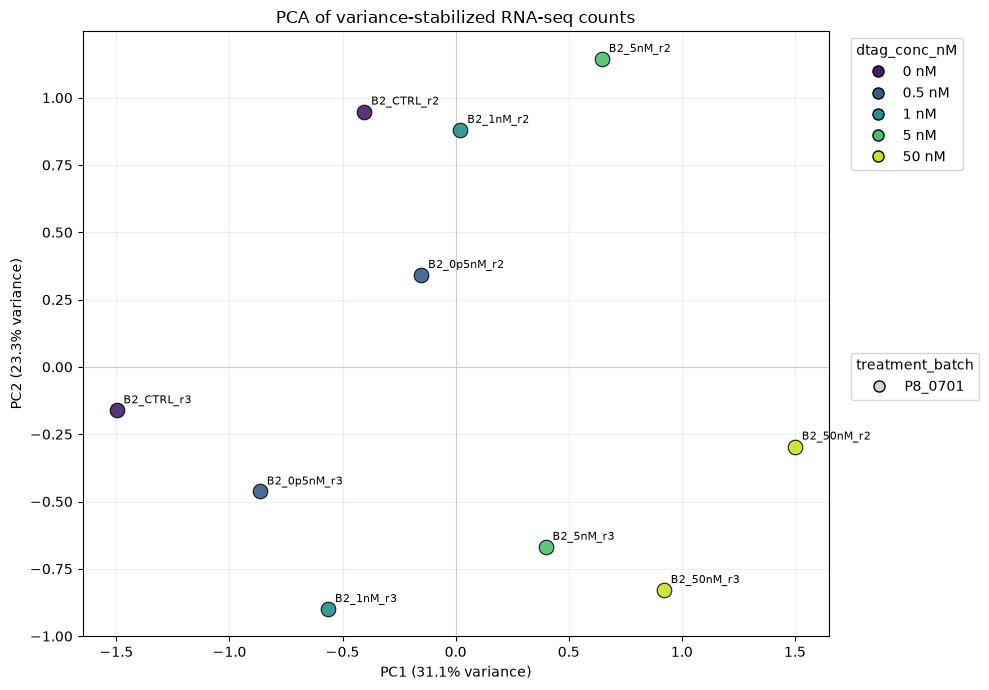

PCA scores saved to: C:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\results\counts\vst_pca_scores.csv
PCA figure saved to: C:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\results\counts\vst_pca_plot.png


In [80]:
# Task 1B-2: PCA of VST counts
# Colour = dTAG concentration
# Shape = treatment batch
# =========================================================

# ---------------------------------------------------------
# 1. Settings, to modify as needed
# ---------------------------------------------------------

n_top_genes = 500

colour_by = "dtag_conc_nM"
shape_by = "treatment_batch"

# Explicitly include specific samples.
# None = include all available samples.
# Example:
# include_samples = ["B2_CTRL_r1", "B2_CTRL_r2", "B2_0.5_r1"]
include_samples = None

# Explicitly exclude specific samples.
# Example:
# exclude_samples = ["B2_CTRL_r1"]
# exclude r1: "B2_CTRL_r1", "B2_0p5nM_r1", "B2_1nM_r1","B2_5nM_r1" ,"B2_50nM_r1"
exclude_samples = ["B2_CTRL_r1", "B2_0p5nM_r1", "B2_1nM_r1","B2_5nM_r1" ,"B2_50nM_r1"]

# Optional metadata-based filtering.
# None = no metadata filtering.
# Examples:
# sample_query = "treatment_batch == 2"
# sample_query = "dtag_conc_nM <= 5"
# sample_query = "treatment_batch != 1"
sample_query = None


# ---------------------------------------------------------
# 1. Prepare expression matrix
# ---------------------------------------------------------

# Make a copy so the original vst_counts is not modified
vst_pca = vst_counts.copy()

# If gene_id is still a regular column, make it the row index
if "gene_id" in vst_pca.columns:
    vst_pca = vst_pca.set_index("gene_id")



# ---------------------------------------------------------
# 2. Select samples
# ---------------------------------------------------------

# Start from metadata
metadata_pca = metadata.copy()

# Apply optional metadata query
if sample_query is not None:
    metadata_pca = metadata_pca.query(sample_query)

# Apply explicit inclusion list
if include_samples is not None:
    metadata_pca = metadata_pca[
        metadata_pca["sample_id"].isin(include_samples)
    ]

# Apply explicit exclusion list
if exclude_samples:
    metadata_pca = metadata_pca[
        ~metadata_pca["sample_id"].isin(exclude_samples)
    ]

# Keep only samples that exist in BOTH metadata and VST counts
sample_ids = [
    sample_id
    for sample_id in metadata_pca["sample_id"]
    if sample_id in vst_pca.columns
]

# Select only those sample columns
vst_pca = vst_pca.loc[:, sample_ids]

print(f"Samples used for PCA: {len(sample_ids)}")
print(sample_ids)

gene_variances = vst_pca.var(
    axis=1,
    ddof=1
)

top_gene_ids = (
    gene_variances
    .nlargest(n_top_genes)
    .index
)

pca_expression = vst_pca.loc[top_gene_ids]

print(f"Genes used for PCA: {pca_expression.shape[0]}")


# ---------------------------------------------------------
# 3. Transpose to samples × genes
# ---------------------------------------------------------

pca_expression = pca_expression.T

# ---------------------------------------------------------
# 4. Run PCA
# ---------------------------------------------------------

# sklearn PCA automatically centers each gene.
# Do not use StandardScaler after VST because scaling each
# gene to unit variance would give low-variance/noisy genes
# equal weight.

pca = PCA(
    n_components=2
)

coordinates = pca.fit_transform(pca_expression)

pc1_variance, pc2_variance = (
    pca.explained_variance_ratio_[:2] * 100
)

print(f"PC1 explained variance: {pc1_variance:.2f}%")
print(f"PC2 explained variance: {pc2_variance:.2f}%")

# ---------------------------------------------------------
# 5. Build PCA score table
# ---------------------------------------------------------

# First create scores using the exact order used by PCA
pca_scores = pd.DataFrame({
    "sample_id": pca_expression.index,
    "PC1": coordinates[:, 0],
    "PC2": coordinates[:, 1]
})

# Add metadata by matching sample_id
pca_scores = pca_scores.merge(
    metadata_pca[
        [
            "sample_id",
            colour_by,
            shape_by
        ]
    ],
    on="sample_id",
    how="left",
    validate="one_to_one"
)

# Make sure every sample matched metadata
if pca_scores[[colour_by, shape_by]].isna().any().any():
    raise ValueError(
        "Some PCA samples could not be matched to metadata."
    )

pca_scores.to_csv(
    scores_path,
    index=False
)

display(pca_scores)

# ---------------------------------------------------------
# 6. Assign colors
# ---------------------------------------------------------

color_values = sorted(
    pca_scores[colour_by].unique()
)

color_palette = plt.cm.viridis(
    np.linspace(
        0.08,
        0.92,
        len(color_values)
    )
)

color_map = dict(
    zip(
        color_values,
        color_palette
    )
)

# ---------------------------------------------------------
# 7. Assign marker shapes
# ---------------------------------------------------------

shape_values = sorted(
    pca_scores[shape_by].unique()
)

available_markers = [
    "o",
    "s",
    "^",
    "D",
    "P",
    "X",
    "v",
    "<",
    ">"
]

if len(shape_values) > len(available_markers):
    raise ValueError(
        "More groups than available marker shapes."
    )

marker_map = dict(
    zip(
        shape_values,
        available_markers
    )
)


# ---------------------------------------------------------
# 8. Draw PCA plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for _, sample in pca_scores.iterrows():

    ax.scatter(
        sample["PC1"],
        sample["PC2"],
        color=color_map[sample[colour_by]],
        marker=marker_map[sample[shape_by]],
        s=110,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        zorder=3
    )

    ax.annotate(
        sample["sample_id"],
        (
            sample["PC1"],
            sample["PC2"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )


# ---------------------------------------------------------
# 9. Create legends
# ---------------------------------------------------------

color_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color_map[value],
        markeredgecolor="black",
        markersize=8,
        label=f"{value:g} nM"
    )
    for value in color_values
]

shape_legend = [
    Line2D(
        [0],
        [0],
        marker=marker_map[value],
        linestyle="",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        markersize=8,
        label=str(value)
    )
    for value in shape_values
]

first_legend = ax.legend(
    handles=color_legend,
    title=colour_by,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.add_artist(first_legend)

ax.legend(
    handles=shape_legend,
    title=shape_by,
    bbox_to_anchor=(1.02, 0.48),
    loc="upper left"
)


# ---------------------------------------------------------
# 10. Format and save
# ---------------------------------------------------------

ax.axhline(
    0,
    color="lightgray",
    linewidth=0.8,
    zorder=1
)

ax.axvline(
    0,
    color="lightgray",
    linewidth=0.8,
    zorder=1
)

ax.set_xlabel(
    f"PC1 ({pc1_variance:.1f}% variance)"
)

ax.set_ylabel(
    f"PC2 ({pc2_variance:.1f}% variance)"
)

ax.set_title(
    "PCA of variance-stabilized RNA-seq counts"
)

ax.grid(
    alpha=0.2,
    zorder=0
)

plt.tight_layout()

plt.savefig(
    pca_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PCA scores saved to:", scores_path.resolve())
print("PCA figure saved to:", pca_plot_path.resolve())

,sample_id,PC1,PC2,mng_measured_pct
0,B2_50nM_r2,1.499474,-0.295693,0.038028
1,B2_5nM_r2,0.646465,1.144314,0.156338
2,B2_1nM_r2,0.020902,0.880752,NaN
3,B2_0p5nM_r2,-0.152222,0.341693,0.811268
4,B2_CTRL_r2,-0.404150,0.948549,1.000000
5,B2_50nM_r3,0.920180,-0.828692,0.029957
6,B2_5nM_r3,0.397694,-0.668081,0.154066
7,B2_1nM_r3,-0.563994,-0.899199,0.479315
8,B2_0p5nM_r3,-0.865414,-0.462691,0.823109
9,B2_CTRL_r3,-1.498936,-0.160954,1.000000


Excluded because mng_measured_pct is missing:
  B2_1nM_r2


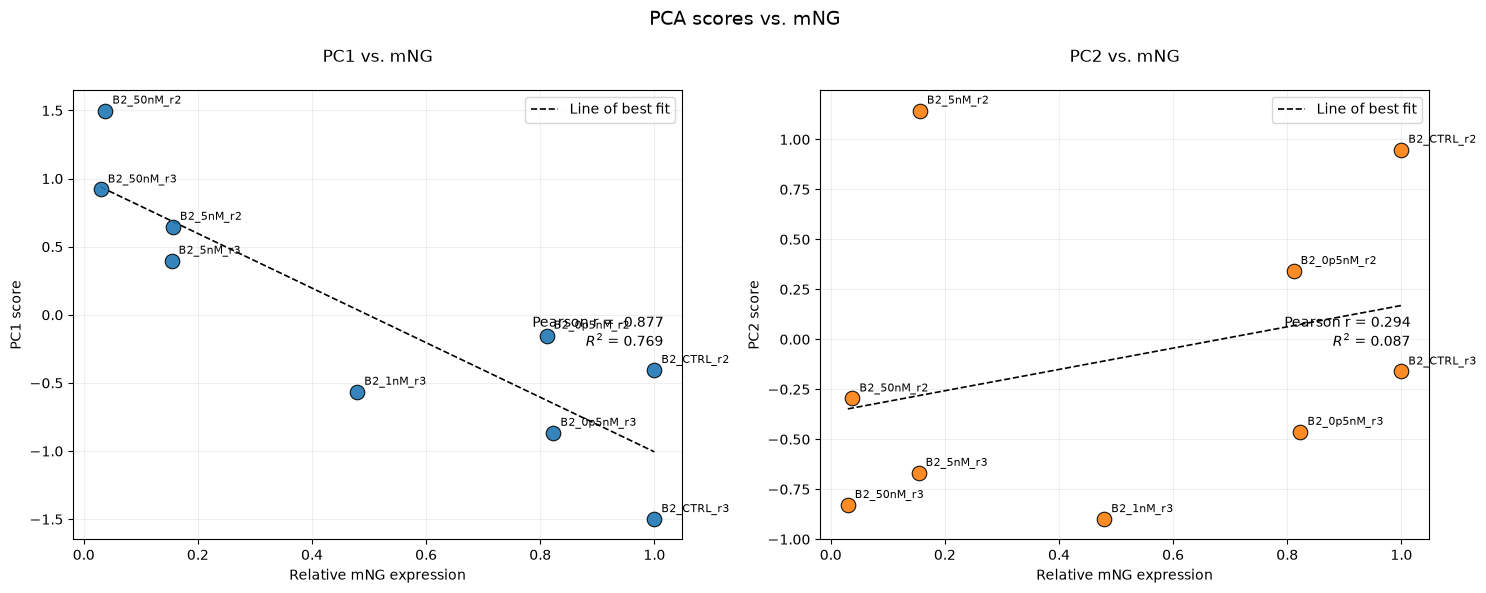

,sample_id,PC1,PC2,mng_measured_pct
0,B2_50nM_r2,1.499474,-0.295693,0.038028
1,B2_5nM_r2,0.646465,1.144314,0.156338
3,B2_0p5nM_r2,-0.152222,0.341693,0.811268
4,B2_CTRL_r2,-0.404150,0.948549,1.000000
5,B2_50nM_r3,0.920180,-0.828692,0.029957
6,B2_5nM_r3,0.397694,-0.668081,0.154066
7,B2_1nM_r3,-0.563994,-0.899199,0.479315
8,B2_0p5nM_r3,-0.865414,-0.462691,0.823109
9,B2_CTRL_r3,-1.498936,-0.160954,1.000000


Samples plotted: 9
PC1 versus mNG Pearson r: -0.877
PC2 versus mNG Pearson r: 0.294
Figure saved to: C:\Users\edwar\Desktop\dTAG_analysis\rai1-dosage-rnaseq\results\counts\vst_pc_scores_vs_mng.png


In [59]:
# TASK 1B-3
# Plot PC1 and PC2 against measured mNeonGreen percentage
# ============================================================


# ------------------------------------------------------------
# 1. Combine PCA scores with mNG measurements
# ------------------------------------------------------------

plot_data = pca_scores[
    [
        "sample_id",
        "PC1",
        "PC2",
    ]
].merge(
    metadata[
        [
            "sample_id",
            "mng_measured_pct",
        ]
    ],
    on="sample_id",
    how="left",
    validate="one_to_one",
)

display(plot_data)



# ------------------------------------------------------------
# 2. Remove samples without valid measurements
# ------------------------------------------------------------

missing_mng = plot_data.loc[
    plot_data["mng_measured_pct"].isna(),
    "sample_id",
].tolist()

if missing_mng:
    print(
        "Excluded because mng_measured_pct is missing:"
    )

    for sample_id in missing_mng:
        print(f"  {sample_id}")

plot_data = plot_data.dropna(
    subset=[
        "PC1",
        "PC2",
        "mng_measured_pct",
    ]
).copy()


# ------------------------------------------------------------
# 3. Function for one PC-versus-mNG plot
# ------------------------------------------------------------

def plot_pc_against_mng(
    axis,
    data,
    pc_column,
    point_colour,
):

    x = data["mng_measured_pct"].to_numpy()
    y = data[pc_column].to_numpy()

    # Plot the samples.
    axis.scatter(
        x,
        y,
        s=110,
        color=point_colour,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        zorder=3,
    )

    # Add each sample ID beside its point.
    for _, sample in data.iterrows():
        axis.annotate(
            sample["sample_id"],
            (
                sample["mng_measured_pct"],
                sample[pc_column],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    # Calculate a linear trend line.
    slope, intercept = np.polyfit(x, y, 1)

    line_x = np.linspace(
        x.min(),
        x.max(),
        100,
    )

    line_y = slope * line_x + intercept

    axis.plot(
        line_x,
        line_y,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Line of best fit",
        zorder=2,
    )

    # Calculate Pearson r and R-squared
    correlation = np.corrcoef(x, y)[0, 1]
    r_squared = correlation ** 2

    axis.text(
        0.97,
        0.50,
        f"Pearson r = {correlation:.3f}\n"
        f"$R^2$ = {r_squared:.3f}",
        transform=axis.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        fontsize=10,
    )

    axis.set_xlabel(
        "Relative mNG expression"
    )

    axis.set_ylabel(
        f"{pc_column} score"
    )

    axis.set_title(
        f"{pc_column} vs. mNG\n"
    )

    axis.grid(
        alpha=0.2,
        zorder=0,
    )

    axis.legend()

    return correlation


# ------------------------------------------------------------
# 7. Create the PC1 and PC2 plots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6),
)

pc1_correlation = plot_pc_against_mng(
    axis=axes[0],
    data=plot_data,
    pc_column="PC1",
    point_colour="#1f77b4",
)

pc2_correlation = plot_pc_against_mng(
    axis=axes[1],
    data=plot_data,
    pc_column="PC2",
    point_colour="#ff7f0e",
)

fig.suptitle(
    "PCA scores vs. mNG",
    fontsize=14,
)

plt.tight_layout()


fig.savefig(
    pc_scores_vs_mng_plot_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ------------------------------------------------------------
# 8. Display the merged values and results
# ------------------------------------------------------------

display(plot_data)

print(f"Samples plotted: {len(plot_data)}")
print(f"PC1 versus mNG Pearson r: {pc1_correlation:.3f}")
print(f"PC2 versus mNG Pearson r: {pc2_correlation:.3f}")
print(f"Figure saved to: {pc_scores_vs_mng_plot_path.resolve()}")

<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:72: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:72: SyntaxWarning: invalid escape sequence '\m'
C:\Users\edwar\AppData\Local\Temp\ipykernel_33732\2471687866.py:71: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathit{RAI1}$ mRNA level")
C:\Users\edwar\AppData\Local\Temp\ipykernel_33732\2471687866.py:72: SyntaxWarning: invalid escape sequence '\m'
  plt.title("$\mathit{RAI1}$ expression vs. measured mNG")


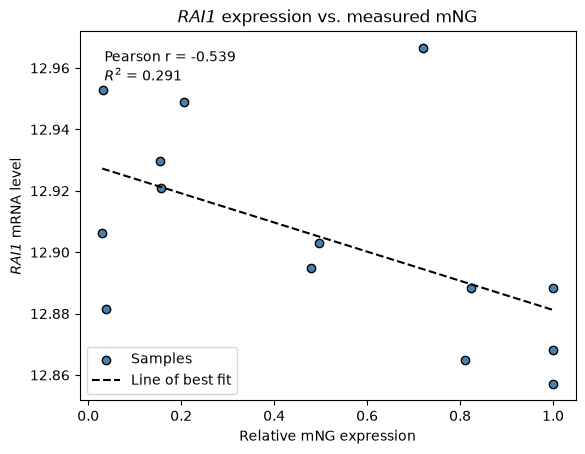

Samples included: 14
Samples excluded: 1
Pearson r = -0.539
R-squared = 0.291


In [146]:
# TASK 1B-4
# Plot RAI1 counts against measured mNeonGreen percentage
# ============================================================

# ------------------------------------------------------------
# 1. Load the variables
# ------------------------------------------------------------

# RAI1 count after DESeq2 normalization and VST
rai1_counts = (
    vst_counts
    .set_index("gene_id")
    .loc[rai1_gene_id]
)

rai1_table = (
    rai1_counts
    .rename("rai1_vst")
    .rename_axis("sample_id")
    .reset_index()
)

dtag_conc = metadata[
    ["sample_id", "mng_measured_pct"]
]


plot_data = dtag_conc.merge(
    rai1_table,
    on="sample_id",
    how="inner",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 2. Plot RAI1 counts across dosage
# ------------------------------------------------------------

fit_data = plot_data.dropna(
    subset=["mng_measured_pct"]
).copy()

x = fit_data["mng_measured_pct"].to_numpy(dtype=float)
y = fit_data["rai1_vst"].to_numpy(dtype=float)

slope, intercept = np.polyfit(x, y, 1)
r_value = np.corrcoef(x, y)[0, 1]
r_squared = r_value ** 2

line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept

plt.scatter(
    x,
    y,
    color="steelblue",
    edgecolor="black",
    label="Samples"
)

plt.plot(
    line_x,
    line_y,
    color="black",
    linestyle="--",
    label="Line of best fit"
)

plt.xlabel("Relative mNG expression")
plt.ylabel("$\mathit{RAI1}$ mRNA level")
plt.title("$\mathit{RAI1}$ expression vs. measured mNG")

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r_value:.3f}\n"
    f"$R^2$ = {r_squared:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.legend()
plt.show()

print(f"Samples included: {len(fit_data)}")
print(f"Samples excluded: {len(plot_data) - len(fit_data)}")
print(f"Pearson r = {r_value:.3f}")
print(f"R-squared = {r_squared:.3f}")

Samples included: 14
Samples excluded: 1
  sample_id  mng_measured_pct  rna_yield_ng
 B2_50nM_r1          0.031484      32944.92
  B2_5nM_r1          0.205397      34607.40
  B2_1nM_r1          0.495775      26536.80
B2_0p5nM_r1          0.721139      34013.52
 B2_CTRL_r1          1.000000      34746.54
 B2_50nM_r2          0.038028      26312.34
  B2_5nM_r2          0.156338      27980.04
B2_0p5nM_r2          0.811268      24633.12
 B2_CTRL_r2          1.000000      26375.52
 B2_50nM_r3          0.029957      27236.70
  B2_5nM_r3          0.154066      27816.18
  B2_1nM_r3          0.479315      27712.62
B2_0p5nM_r3          0.823109      27232.20
 B2_CTRL_r3          1.000000      25378.98
x: [0.0314843 0.2053973 0.4957746 0.7211394 1.        0.0380282 0.156338
 0.8112676 1.        0.0299572 0.1540656 0.4793153 0.823109  1.       ]
y: [32944.92 34607.4  26536.8  34013.52 34746.54 26312.34 27980.04 24633.12
 26375.52 27236.7  27816.18 27712.62 27232.2  25378.98]
Finite x: True
Finite 

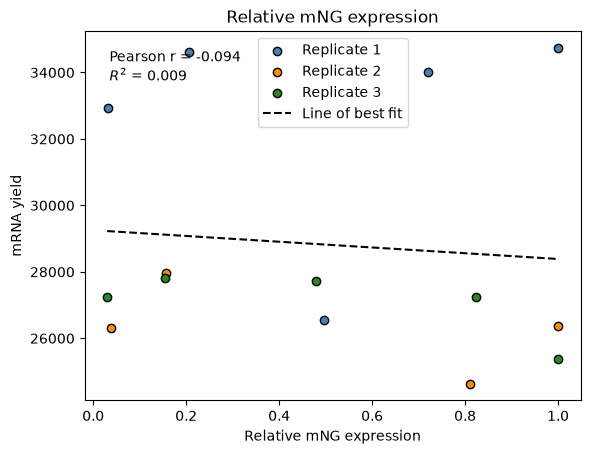

Samples included: 14
Samples excluded: 1
Pearson r = -0.094
R-squared = 0.009


In [148]:
# TASK 1B-5
# Plot rna_yield_ng / cells_harvested against measured dosage
# ============================================================

plot_data = metadata[
    ["sample_id", "replicate", "mng_measured_pct", "rna_yield_ng"]
].copy()

fit_data = plot_data.copy()

for column in ["mng_measured_pct", "rna_yield_ng"]:
    fit_data[column] = pd.to_numeric(
        fit_data[column],
        errors="coerce"
    )

fit_data = (
    fit_data
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["mng_measured_pct", "rna_yield_ng"])
)

x = fit_data["mng_measured_pct"].to_numpy(dtype=float)
y = fit_data["rna_yield_ng"].to_numpy(dtype=float)

print(f"Samples included: {len(fit_data)}")
print(f"Samples excluded: {len(plot_data) - len(fit_data)}")

print(fit_data[["sample_id", "mng_measured_pct", "rna_yield_ng"]].to_string(index=False))
print("x:", x)
print("y:", y)
print("Finite x:", np.isfinite(x).all())
print("Finite y:", np.isfinite(y).all())
print("Different x-values:", np.unique(x).size)
valid = np.isfinite(x) & np.isfinite(y)

print("Samples excluded from fit:", (~valid).sum())

x = x[valid]
y = y[valid]

slope, intercept = np.polyfit(x, y, 1)


slope, intercept = np.polyfit(x, y, 1)
r_value = np.corrcoef(x, y)[0, 1]
r_squared = r_value ** 2

line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept

replicate_colours = {
    1: "steelblue",
    2: "darkorange",
    3: "forestgreen",
}

for replicate, group in fit_data.groupby("replicate"):
    plt.scatter(
        group["mng_measured_pct"],
        group["rna_yield_ng"],
        color=replicate_colours[int(replicate)],
        edgecolor="black",
        label=f"Replicate {int(replicate)}"
    )

plt.plot(
    line_x,
    line_y,
    color="black",
    linestyle="--",
    label="Line of best fit"
)

plt.xlabel("Relative mNG expression")
plt.ylabel("mRNA yield")
plt.title("Relative mNG expression")

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r_value:.3f}\n"
    f"$R^2$ = {r_squared:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.legend()
plt.show()

print(f"Samples included: {len(fit_data)}")
print(f"Samples excluded: {len(plot_data) - len(fit_data)}")
print(f"Pearson r = {r_value:.3f}")
print(f"R-squared = {r_squared:.3f}")

Samples used for heatmap: 15
Genes used for correlation: 500


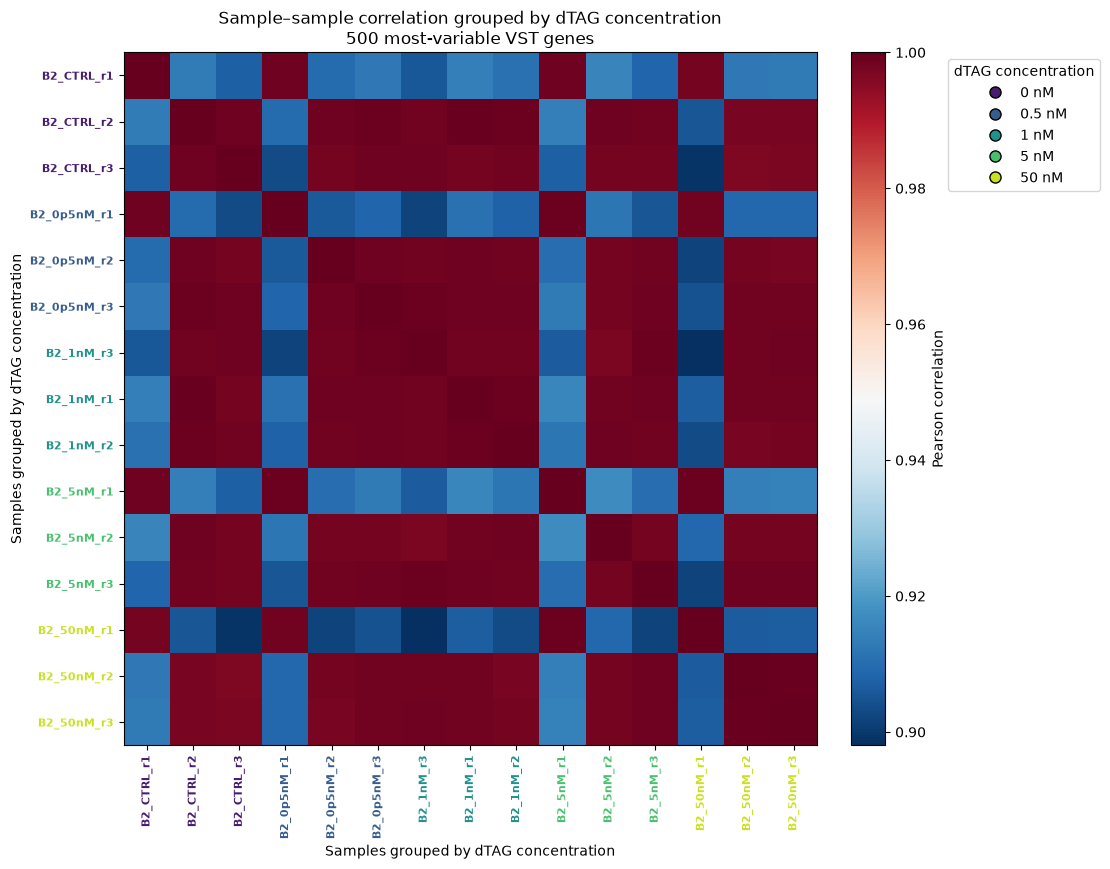

In [99]:
# TASK 1B-6: Sample–sample correlation heat map with clustering
# Samples are grouped by dosage
# Input: VST-normalized gene expression
# Label colour: dTAG concentration
# ============================================================

# ---------------------------------------------------------
# 1. Settings, to modify as needed
# ---------------------------------------------------------

n_top_genes = 500

colour_by = "dtag_conc_nM"
shape_by = "treatment_batch"

# Explicitly include specific samples.
# None = include all available samples.
# Example:
# include_samples = ["B2_CTRL_r1", "B2_CTRL_r2", "B2_0.5_r1"]
include_samples = None

# Explicitly exclude specific samples.
# Example:
# exclude_samples = ["B2_CTRL_r1"]
# "B2_CTRL_r1", "B2_0p5nM_r1", "B2_1nM_r1","B2_5nM_r1" ,"B2_50nM_r1"
exclude_samples = []

# Optional metadata-based filtering.
# None = no metadata filtering.
# Examples:
# sample_query = "treatment_batch == 2"
# sample_query = "dtag_conc_nM <= 5"
# sample_query = "treatment_batch != 1"
sample_query = None


# ---------------------------------------------------------
# 2. Select samples
# ---------------------------------------------------------
vst_heatmap = vst_counts.copy()
metadata_heatmap = metadata.copy()

# Apply optional metadata query
if sample_query is not None:
    metadata_heatmap = metadata_heatmap.query(sample_query)

# Apply explicit inclusion list
if include_samples is not None:
    metadata_heatmap = metadata_heatmap[
        metadata_heatmap["sample_id"].isin(include_samples)
    ]

# Apply explicit exclusion list
if exclude_samples:
    metadata_heatmap = metadata_heatmap[
        ~metadata_heatmap["sample_id"].isin(exclude_samples)
    ]

# Keep only samples that exist in BOTH metadata and VST counts
sample_ids = [
    sample_id
    for sample_id in metadata_heatmap["sample_id"]
    if sample_id in vst_heatmap.columns
]

# Select only those sample columns
vst_heatmap = vst_heatmap.loc[:, sample_ids]

print(f"Samples used for heatmap: {len(sample_ids)}")


# ---------------------------------------------------------
# 3. Select the most-variable genes
# ---------------------------------------------------------

gene_variances = vst_heatmap.var(
    axis=1,
    ddof=1
)

gene_variances = gene_variances.loc[
    gene_variances.notna()
    & (gene_variances > 0)
]

number_of_genes = min(
    n_top_genes,
    len(gene_variances)
)

top_gene_ids = (
    gene_variances
    .nlargest(number_of_genes)
    .index
)

expression = vst_heatmap.loc[
    top_gene_ids
]

print(
    f"Genes used for correlation: "
    f"{number_of_genes}"
)

correlation = expression.corr(method="pearson")


# ---------------------------------------------------------
# 4. Group by dosage and cluster within each dosage
# ---------------------------------------------------------

selected_metadata = (
    metadata_heatmap
    .set_index("sample_id")
    .loc[sample_ids]
    .copy()
)

dosages = sorted(
    selected_metadata[
        "dtag_conc_nM"
    ].unique()
)

clustered_ids = []

for dosage in dosages:

    # Find samples belonging to this concentration.
    dosage_sample_ids = (
        selected_metadata.loc[
            selected_metadata[
                "dtag_conc_nM"
            ] == dosage
        ]
        .index
        .tolist()
    )

    if len(dosage_sample_ids) == 1:

        # Clustering is unnecessary for a single sample.
        dosage_clustered_ids = dosage_sample_ids

    else:

        # Extract correlations within this dosage group.
        dosage_correlation = correlation.loc[
            dosage_sample_ids,
            dosage_sample_ids
        ]

        # Convert correlation to distance.
        dosage_distance = (
            1.0
            - dosage_correlation.to_numpy(
                dtype=float,
                copy=True
            )
        )

        dosage_distance = np.clip(
            dosage_distance,
            0.0,
            2.0
        )

        np.fill_diagonal(
            dosage_distance,
            0.0
        )

        # Hierarchically cluster this dosage group.
        dosage_tree = linkage(
            squareform(
                dosage_distance,
                checks=False
            ),
            method="average"
        )

        dosage_leaf_positions = leaves_list(
            dosage_tree
        )

        dosage_clustered_ids = [
            dosage_sample_ids[position]
            for position in dosage_leaf_positions
        ]

    clustered_ids.extend(
        dosage_clustered_ids
    )


# Reorder the correlation matrix.
clustered_correlation = correlation.loc[
    clustered_ids,
    clustered_ids
]

# Reorder the metadata identically.
clustered_metadata = selected_metadata.loc[
    clustered_ids
].copy()

clustered_metadata.insert(
    0,
    "display_position",
    range(1, len(clustered_metadata) + 1)
)


# ---------------------------------------------------------
# 5. Assign colours to dTAG concentrations
# ---------------------------------------------------------

dosage_palette = plt.cm.viridis(
    np.linspace(
        0.08,
        0.92,
        len(dosages)
    )
)

dosage_colours = dict(
    zip(
        dosages,
        dosage_palette
    )
)


# ---------------------------------------------------------
# 6. Draw the correlation heat map
# ---------------------------------------------------------

values = clustered_correlation.to_numpy()

off_diagonal = values[
    ~np.eye(
        len(values),
        dtype=bool
    )
]

colour_min = float(
    off_diagonal.min()
)

fig, heatmap_ax = plt.subplots(
    figsize=(11, 9)
)

image = heatmap_ax.imshow(
    values,
    cmap="RdBu_r",
    vmin=colour_min,
    vmax=1.0,
    interpolation="nearest",
    aspect="equal"
)

positions = np.arange(
    len(clustered_ids)
)

heatmap_ax.set_xticks(positions)
heatmap_ax.set_yticks(positions)

heatmap_ax.set_xticklabels(
    clustered_ids,
    rotation=90,
    fontsize=8
)

heatmap_ax.set_yticklabels(
    clustered_ids,
    fontsize=8
)


# ---------------------------------------------------------
# 7. Colour sample labels by dTAG concentration
# ---------------------------------------------------------

for label, sample_id in zip(
    heatmap_ax.get_xticklabels(),
    clustered_ids
):
    dosage = clustered_metadata.loc[
        sample_id,
        "dtag_conc_nM"
    ]

    label.set_color(
        dosage_colours[dosage]
    )

    label.set_fontweight("bold")


for label, sample_id in zip(
    heatmap_ax.get_yticklabels(),
    clustered_ids
):
    dosage = clustered_metadata.loc[
        sample_id,
        "dtag_conc_nM"
    ]

    label.set_color(
        dosage_colours[dosage]
    )

    label.set_fontweight("bold")


# ---------------------------------------------------------
# 8. Add colour bar and dosage legend
# ---------------------------------------------------------

colour_bar = fig.colorbar(
    image,
    ax=heatmap_ax,
    fraction=0.046,
    pad=0.04
)

colour_bar.set_label(
    "Pearson correlation"
)

dosage_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=dosage_colours[dosage],
        markeredgecolor="black",
        markersize=8,
        label=f"{dosage:g} nM"
    )
    for dosage in dosages
]

heatmap_ax.legend(
    handles=dosage_legend,
    title="dTAG concentration",
    bbox_to_anchor=(1.18, 1),
    loc="upper left"
)


# ---------------------------------------------------------
# 9. Format the heat map
# ---------------------------------------------------------

heatmap_ax.set_xlabel(
    "Samples grouped by dTAG concentration"
)

heatmap_ax.set_ylabel(
    "Samples grouped by dTAG concentration"
)

heatmap_ax.set_title(
    f"Sample–sample correlation grouped by dTAG concentration\n"
    f"{number_of_genes} most-variable VST genes"
)


plt.show()
